# Core Queries

This notebook applies SQL concepts to real business questions using the Olist dataset. Each section focuses on a specific analytical task.

In [1]:
from olist_analytics.db import setup
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

engine, q = setup()

Connected.


### 3.1 

What are the 10 most recent orders, including the customer's city and state?

In [20]:
recent_orders = q("""
    SELECT
      o.order_id,
      c.customer_city,
      c.customer_state,
      o.order_status,
      o.order_purchase_timestamp
    FROM olist_orders o
    JOIN olist_customers c ON o.customer_id = c.customer_id
    ORDER BY o.order_purchase_timestamp DESC
    LIMIT 5
""")

recent_orders

,order_id,customer_city,customer_state,order_status,order_purchase_timestamp
0,10a045cdf6a5650c21e9cfeb60384c16,sorocaba,SP,canceled,2018-10-17 17:30:18
1,b059ee4de278302d550a3035c4cdb740,picos,PI,canceled,2018-10-16 20:16:02
2,a2ac6dad85cf8af5b0afb510a240fe8c,registro,SP,canceled,2018-10-03 18:55:29
3,616fa7d4871b87832197b2a137a115d2,pirai,RJ,canceled,2018-10-01 15:30:09
4,392ed9afd714e3c74767d0c4d3e3f477,guarulhos,SP,canceled,2018-09-29 09:13:03


How many orders were placed per status?

In [3]:
status = q("""
    SELECT
      order_status,
      COUNT(*) AS order_count
    FROM olist_orders
    GROUP BY order_status
    ORDER BY order_count DESC
""")

status

,order_status,order_count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


### 3.2

Which delivered orders had a total value over $500?

In [4]:
high_value = q("""
    SELECT
      o.order_id,
      o.order_purchase_timestamp,
      ROUND(SUM(oi.price), 2) AS order_value
    FROM olist_orders o
    JOIN olist_order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY 1, 2
    HAVING SUM(oi.price) > 500
    ORDER BY order_value DESC
    LIMIT 5
""")

high_value

,order_id,order_purchase_timestamp,order_value
0,03caa2c082116e1d31e67e9ae3700499,2017-09-29 15:24:52,13440.0
1,736e1922ae60d0d6a89247b851902527,2018-07-15 14:49:44,7160.0
2,0812eb902a67711a1cb742b3cdaa65ae,2017-02-12 20:37:36,6735.0
3,fefacc66af859508bf1a7934eab1e97f,2018-07-25 18:10:17,6729.0
4,f5136e38d1a14a4dbd87dff67da82701,2017-05-24 18:14:34,6499.0


How many delivered orders were placed each week in the first half of 2018?

In [5]:
date_range = q("""
    SELECT
      DATE_TRUNC('week', order_purchase_timestamp) AS week,
      COUNT(*) AS order_count
    FROM olist_orders
    WHERE order_purchase_timestamp BETWEEN '2018-01-01' AND '2018-06-30'
      AND order_status = 'delivered'
    GROUP BY 1
    ORDER BY 1
    LIMIT 5
""")

date_range

,week,order_count
0,2018-01-01,1341
1,2018-01-08,1738
2,2018-01-15,1704
3,2018-01-22,1545
4,2018-01-29,1561


Return products in electronics-related categories ordered by weight.

In [6]:
category_products = q("""
    SELECT
      o.product_id,
      t.product_category_name_english,
      o.product_weight_g,
      o.product_photos_qty
    FROM olist_products o
    JOIN olist_product_category_name_translation t ON o.product_category_name = t.product_category_name
    WHERE t.product_category_name_english IN ('electronics', 'computers_accessories', 'telephony')
    ORDER BY o.product_weight_g DESC
    LIMIT 5
""")

category_products

,product_id,product_category_name_english,product_weight_g,product_photos_qty
0,ae4a8a8e8a8f8850c720e68c182b1625,electronics,24050.0,4
1,c3f8ee7e05c01c61ab863e336b0f2e5e,computers_accessories,24050.0,4
2,17b41b007356c9b333b4e7c1fcedb066,electronics,23500.0,2
3,e02468b92277cf781a87051ff6d80e1c,computers_accessories,20800.0,4
4,e6a5c36890bb6b3ed8a1dd32a9930b77,electronics,18700.0,4


### 3.3

Return total revenue, order count and average order value by month. Plot as a dual-axis chart.

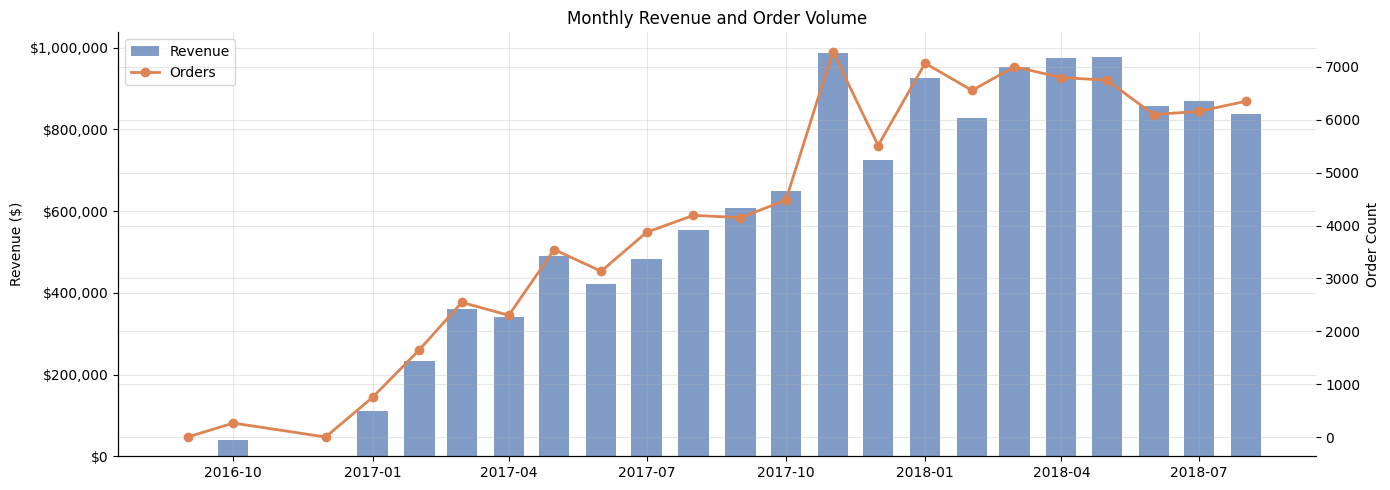

In [7]:
monthly = q("""
    SELECT
      DATE_TRUNC('month', o.order_purchase_timestamp) AS month,
      COUNT(DISTINCT o.order_id) AS order_count,
      ROUND(SUM(oi.price), 2) AS revenue,
      ROUND(AVG(oi.price), 2) AS avg_order_value
    FROM olist_orders o
    JOIN olist_order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY 1
    ORDER BY 1
""")

from datetime import timedelta
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.bar(monthly["month"], monthly["revenue"], color="#4C72B0", alpha=0.7, label="Revenue", width=timedelta(days=20))
ax2.plot(monthly["month"], monthly["order_count"], color="#DD8452", linewidth=2, marker="o", label="Orders")
ax1.set_ylabel("Revenue ($)")
ax2.set_ylabel("Order Count")
ax1.set_title("Monthly Revenue and Order Volume")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

Order volume peaked in November 2017 and plateaued through 2018, yet revenue continued to climb. This suggests that average order value increased over time; customers were placing fewer incremental orders but spending more per transaction.

What are the top 10 product categories by revenue? Plot as a horizontal bar chart.

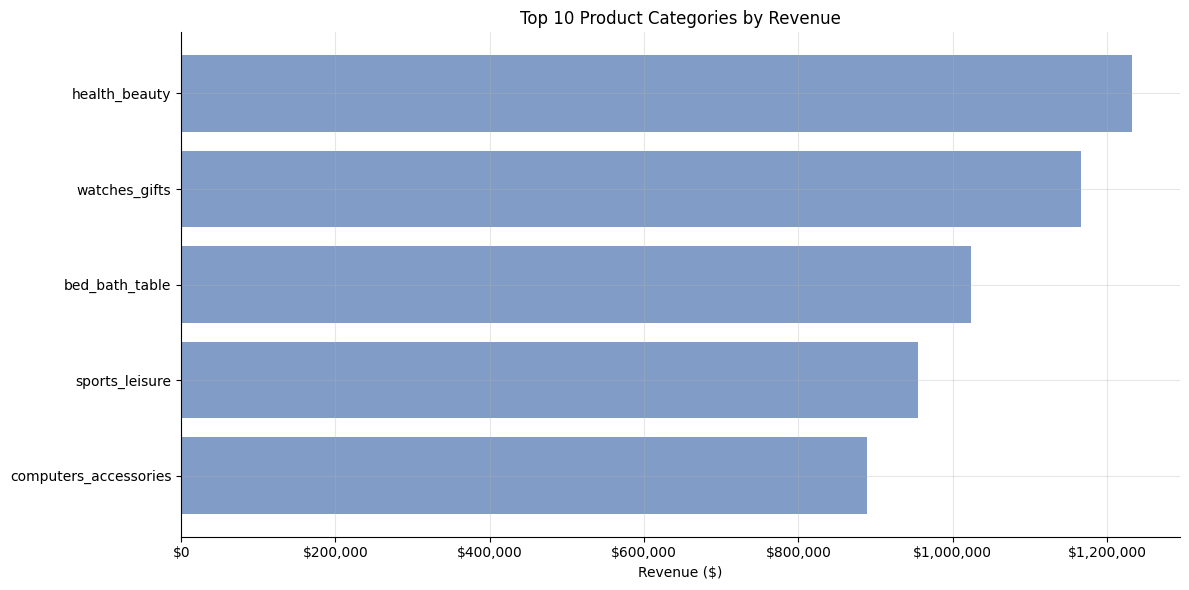

In [8]:
top_categories = q("""
    SELECT
      COALESCE(t.product_category_name_english, 'unknown') AS category,
      COUNT(DISTINCT o.order_id) AS order_count,
      ROUND(SUM(oi.price), 2) AS revenue
    FROM olist_order_items oi
    JOIN olist_orders o   ON oi.order_id = o.order_id
    JOIN olist_products p ON oi.product_id = p.product_id
    LEFT JOIN olist_product_category_name_translation t ON p.product_category_name = t.product_category_name
    WHERE o.order_status = 'delivered'
    GROUP BY 1
    ORDER BY revenue DESC
    LIMIT 5
""")

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_categories["category"], top_categories["revenue"], color="#4C72B0", alpha=0.7)
ax.set_xlabel("Revenue ($)")
ax.set_title("Top 10 Product Categories by Revenue")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Which sellers have placed more than 100 orders? Return their state, order count, revenue and average price.

In [9]:
active_sellers = q("""
    SELECT
      oi.seller_id,
      s.seller_state,
      COUNT(DISTINCT oi.order_id) AS order_count,
      ROUND(SUM(oi.price), 2) AS revenue,
      ROUND(AVG(oi.price), 2) AS avg_price
    FROM olist_order_items oi
    JOIN olist_orders o  ON oi.order_id = o.order_id
    JOIN olist_sellers s ON oi.seller_id = s.seller_id
    WHERE o.order_status = 'delivered'
    GROUP BY 1, 2
    HAVING COUNT(DISTINCT oi.order_id) > 100
    ORDER BY revenue DESC
""")

print(f"{len(active_sellers)} sellers with more than 100 orders")
active_sellers.head(5)

208 sellers with more than 100 orders


,seller_id,seller_state,order_count,revenue,avg_price
0,4869f7a5dfa277a7dca6462dcf3b52b2,SP,1124,226987.93,197.72
1,53243585a1d6dc2643021fd1853d8905,BA,348,217940.44,544.85
2,4a3ca9315b744ce9f8e9374361493884,SP,1772,196882.12,101.02
3,fa1c13f2614d7b5c4749cbc52fecda94,SP,578,190917.14,329.74
4,7c67e1448b00f6e969d365cea6b010ab,SP,973,186570.05,137.69


### 3.4

Return every delivered order with the customer's city and state, product category and price.

In [10]:
full_orders = q("""
    SELECT
      o.order_id,
      o.order_purchase_timestamp,
      c.customer_city,
      c.customer_state,
      p.product_category_name,
      oi.price,
      oi.freight_value
    FROM olist_orders o
    JOIN olist_customers c ON o.customer_id = c.customer_id
    JOIN olist_order_items oi ON o.order_id = oi.order_id
    JOIN olist_products p ON oi.product_id = p.product_id
    WHERE o.order_status = 'delivered'
    LIMIT 5
""")

full_orders

,order_id,order_purchase_timestamp,customer_city,customer_state,product_category_name,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-13 08:59:02,campos dos goytacazes,RJ,cool_stuff,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,2017-04-26 10:53:06,santa fe do sul,SP,pet_shop,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:33:31,para de minas,MG,moveis_decoracao,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,2018-08-08 10:00:35,atibaia,SP,perfumaria,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04 13:57:51,varzea paulista,SP,ferramentas_jardim,199.90,18.14


Return delivered orders with their review score and delivery time.

In [11]:
orders_with_reviews = q("""
    SELECT
      o.order_id,
      o.order_purchase_timestamp,
      r.review_score,
      DATE_PART('day', o.order_delivered_customer_date - o.order_purchase_timestamp) AS delivery_days
    FROM olist_orders o
    LEFT JOIN olist_order_reviews r ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    LIMIT 5
""")

has_review = orders_with_reviews["review_score"].notna().mean()
print(f"Orders with a review: {has_review:.1%}")

Orders with a review: 100.0%


Which customers have never placed an order?

In [12]:
no_orders = q("""
    SELECT
      c.customer_unique_id,
      c.customer_city,
      c.customer_state
    FROM olist_customers c
    LEFT JOIN olist_orders o ON c.customer_id = o.customer_id
    WHERE o.order_id IS NULL
    LIMIT 5
""")

print(f"Customers with no orders: {len(no_orders):,}")

Customers with no orders: 0


### 3.5

What percentage of total revenue does each product category contribute? How many categories make up 80% of revenue?

In [13]:
category_share = q("""
    WITH category_revenue AS (
      SELECT
        COALESCE(p.product_category_name, 'unknown') AS category,
        ROUND(SUM(oi.price), 2) AS revenue
      FROM olist_order_items oi
      JOIN olist_orders o ON oi.order_id = o.order_id
      JOIN olist_products p ON oi.product_id = p.product_id
      WHERE o.order_status = 'delivered'
      GROUP BY 1
    )
    SELECT
      category,
      revenue,
      ROUND(revenue / SUM(revenue) OVER () * 100, 1) AS pct_of_total,
      ROUND(SUM(revenue) OVER (ORDER BY revenue DESC) / SUM(revenue) OVER () * 100, 1) AS cumulative_pct
    FROM category_revenue
    ORDER BY revenue DESC
    LIMIT 5
""")

top_80 = category_share[category_share["cumulative_pct"] <= 80]
print(f"{len(top_80)} categories make up 80% of revenue")
category_share.head(20)

5 categories make up 80% of revenue


,category,revenue,pct_of_total,cumulative_pct
0,beleza_saude,1233131.72,9.3,9.3
1,relogios_presentes,1166176.98,8.8,18.1
2,cama_mesa_banho,1023434.76,7.7,25.9
3,esporte_lazer,954852.55,7.2,33.1
4,informatica_acessorios,888724.61,6.7,39.8


Which customers spent more than the average customer? Return their total spend and how far above average they are.

In [14]:
above_avg = q("""
    WITH customer_spend AS (
      SELECT
        c.customer_unique_id,
        ROUND(SUM(oi.price), 2) AS total_spent
      FROM olist_customers c
      JOIN olist_orders o ON c.customer_id = o.customer_id
      JOIN olist_order_items oi ON o.order_id = oi.order_id
      WHERE o.order_status = 'delivered'
      GROUP BY 1
    ),
    avg_spend AS (
      SELECT AVG(total_spent) AS avg FROM customer_spend
    )
    SELECT
      cs.customer_unique_id,
      cs.total_spent,
      ROUND(a.avg, 2) AS average_spend,
      ROUND(cs.total_spent - a.avg, 2) AS above_average_by
    FROM customer_spend cs
    CROSS JOIN avg_spend a
    WHERE cs.total_spent > a.avg
    ORDER BY cs.total_spent DESC
    LIMIT 5
""")

print(f"{len(above_avg):,} customers spent above average")
above_avg.head(10)

5 customers spent above average


,customer_unique_id,total_spent,average_spend,above_average_by
0,0a0a92112bd4c708ca5fde585afaa872,13440.0,141.62,13298.38
1,da122df9eeddfedc1dc1f5349a1a690c,7388.0,141.62,7246.38
2,763c8b1c9c68a0229c42c9fc6f662b93,7160.0,141.62,7018.38
3,dc4802a71eae9be1dd28f5d788ceb526,6735.0,141.62,6593.38
4,459bef486812aa25204be022145caa62,6729.0,141.62,6587.38


Calculate month-over-month revenue change. Plot growth rate as a bar chart coloured green for positive months and red for negative.

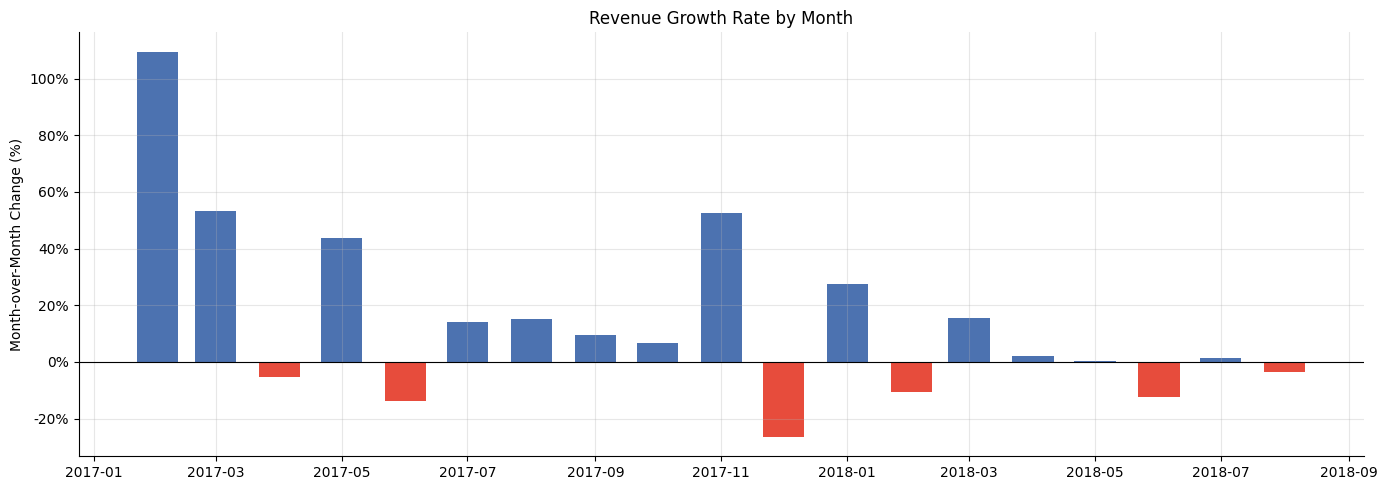

In [15]:
mom = q("""
    WITH monthly AS (
      SELECT
        DATE_TRUNC('month', o.order_purchase_timestamp) AS month,
        ROUND(SUM(oi.price), 2) AS revenue
      FROM olist_orders o
      JOIN olist_order_items oi ON o.order_id = oi.order_id
      WHERE o.order_status = 'delivered'
        AND o.order_purchase_timestamp >= '2017-01-01'
      GROUP BY 1
    )
    SELECT
      month,
      revenue,
      LAG(revenue) OVER (ORDER BY month) AS prev_revenue,
        ROUND(revenue - LAG(revenue) OVER (ORDER BY month), 2) AS change,
        ROUND(
          (revenue - LAG(revenue) OVER (ORDER BY month))
          / NULLIF(LAG(revenue) OVER (ORDER BY month), 0) * 100, 1) AS pct_change
    FROM monthly
    ORDER BY month
""")

from datetime import timedelta
plot_data = mom.dropna(subset=["pct_change"])

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#4C72B0" if x >= 0 else "#e74c3c" for x in plot_data["pct_change"]]
ax.bar(plot_data["month"], plot_data["pct_change"], color=colors, width=timedelta(days=20))
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Month-over-Month Change (%)")
ax.set_title("Revenue Growth Rate by Month")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.tight_layout()
plt.show()

### 3.6

Rank customers by total spend. Include order count and assign each customer to a decile.

In [16]:
customer_rank = q("""
    WITH spend AS (
      SELECT
        c.customer_unique_id,
        ROUND(SUM(oi.price), 2) AS total_spent,
        COUNT(DISTINCT o.order_id) AS order_count
      FROM olist_customers c
      JOIN olist_orders o ON c.customer_id = o.customer_id
      JOIN olist_order_items oi ON o.order_id = oi.order_id
      WHERE o.order_status = 'delivered'
      GROUP BY 1
    )
    SELECT
      customer_unique_id,
      total_spent,
      order_count,
      RANK() OVER (ORDER BY total_spent DESC) AS spend_rank,
      NTILE(10) OVER (ORDER BY total_spent DESC) AS decile
    FROM spend
    ORDER BY total_spent DESC
    LIMIT 5
""")

customer_rank

,customer_unique_id,total_spent,order_count,spend_rank,decile
0,0a0a92112bd4c708ca5fde585afaa872,13440.0,1,1,1
1,da122df9eeddfedc1dc1f5349a1a690c,7388.0,2,2,1
2,763c8b1c9c68a0229c42c9fc6f662b93,7160.0,1,3,1
3,dc4802a71eae9be1dd28f5d788ceb526,6735.0,1,4,1
4,459bef486812aa25204be022145caa62,6729.0,1,5,1


Calculate cumulative revenue over time and plot as a filled area chart.

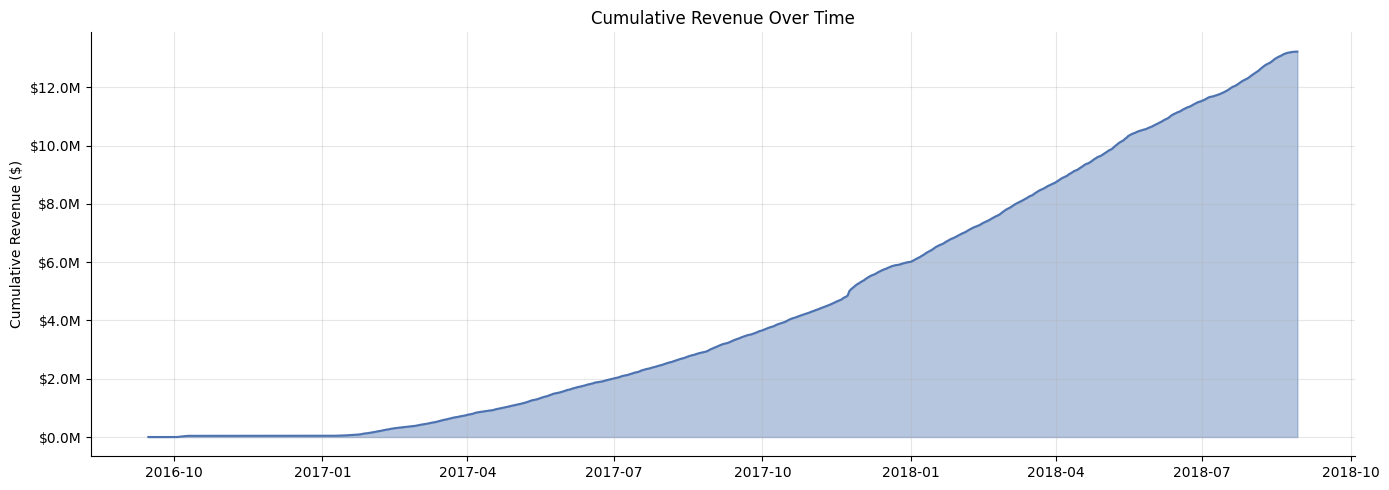

In [17]:
running = q("""
    WITH daily AS (
      SELECT
        DATE_TRUNC('day', o.order_purchase_timestamp) AS day,
        ROUND(SUM(oi.price), 2) AS daily_revenue
      FROM olist_orders o
      JOIN olist_order_items oi ON o.order_id = oi.order_id
      WHERE o.order_status = 'delivered'
      GROUP BY 1
    )
    SELECT
      day,
      daily_revenue,
      ROUND(SUM(daily_revenue) OVER (ORDER BY day), 2) AS cumulative_revenue
    FROM daily
    ORDER BY day
""")

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(running["day"], running["cumulative_revenue"], alpha=0.4, color="#4C72B0")
ax.plot(running["day"], running["cumulative_revenue"], linewidth=1.5, color="#4C72B0")
ax.set_ylabel("Cumulative Revenue ($)")
ax.set_title("Cumulative Revenue Over Time")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.tight_layout()
plt.show()

Return the most recent delivered order per customer using ROW_NUMBER and PARTITION BY.

In [18]:
latest_orders = q("""
    WITH ranked AS (
      SELECT
        c.customer_unique_id,
        o.order_id,
        o.order_purchase_timestamp,
        ROUND(SUM(oi.price), 2) AS order_value,
        ROW_NUMBER() OVER (PARTITION BY c.customer_unique_id ORDER BY o.order_purchase_timestamp DESC) AS rn
      FROM olist_customers c
      JOIN olist_orders o ON c.customer_id = o.customer_id
      JOIN olist_order_items oi ON o.order_id = oi.order_id
      WHERE o.order_status = 'delivered'
      GROUP BY 1, 2, 3
    )
    SELECT customer_unique_id, order_id, order_purchase_timestamp, order_value
    FROM ranked
    WHERE rn = 1
    ORDER BY order_purchase_timestamp DESC
    LIMIT 5
""")

latest_orders

,customer_unique_id,order_id,order_purchase_timestamp,order_value
0,24ac2b4327e25baf39f2119e4228976a,35a972d7f8436f405b56e36add1a7140,2018-08-29 15:00:37,84.99
1,b701bebbdf478f5500348f03aff62121,03ef5dedbe7492bdae72eec50764c43f,2018-08-29 14:52:00,24.90
2,7febafa06d9d8f232a900a2937f04338,168626408cb32af0ffaf76711caae1dc,2018-08-29 14:18:28,45.90
3,5c58de6fb80e93396e2f35642666b693,0b223d92c27432930dfe407c6aea3041,2018-08-29 14:18:23,418.00
4,7a22d14aa3c3599238509ddca4b93b01,52018484704db3661b98ce838612b507,2018-08-29 12:25:59,63.90


Does delivery time affect review score? Group orders into delivery buckets and compare average review scores.

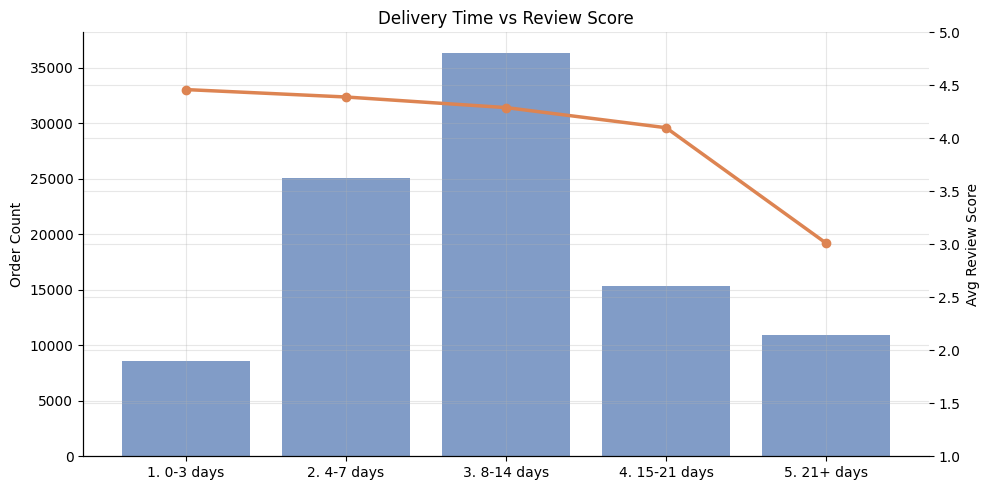

In [19]:
delivery_vs_review = q("""
    SELECT
      CASE
        WHEN DATE_PART('day', o.order_delivered_customer_date - o.order_purchase_timestamp) <= 3  THEN '1. 0-3 days'
        WHEN DATE_PART('day', o.order_delivered_customer_date - o.order_purchase_timestamp) <= 7  THEN '2. 4-7 days'
        WHEN DATE_PART('day', o.order_delivered_customer_date - o.order_purchase_timestamp) <= 14 THEN '3. 8-14 days'
        WHEN DATE_PART('day', o.order_delivered_customer_date - o.order_purchase_timestamp) <= 21 THEN '4. 15-21 days'
        ELSE '5. 21+ days'
      END AS delivery_bucket,
    COUNT(*) AS order_count,
    ROUND(AVG(r.review_score), 2) AS avg_review_score
    FROM olist_orders o
    JOIN olist_order_reviews r ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY 1
    ORDER BY 1
""")

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.bar(delivery_vs_review["delivery_bucket"],
        delivery_vs_review["order_count"], color="#4C72B0", alpha=0.7)
ax2.plot(delivery_vs_review["delivery_bucket"],
         delivery_vs_review["avg_review_score"],
         color="#DD8452", linewidth=2.5, marker="o")
ax1.set_ylabel("Order Count")
ax2.set_ylabel("Avg Review Score")
ax2.set_ylim(1, 5)
ax1.set_title("Delivery Time vs Review Score")
plt.tight_layout()
plt.show()